<a href="https://colab.research.google.com/github/ckCrimson/Field_Dynamic_System/blob/FD_FRAMEWORK_PACKAGE/Research_paper_systems_implementation/random_dice_system_implementation/Random_Dice_System_%E2%80%94_A_Worked_Example_in_the_Field_Dynamic_Systems_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP

In [ ]:
!rm -rf Field_Dynamic_System  # optional: clean old copy
!git clone -b FD_FRAMEWORK_PACKAGE https://github.com/ckCrimson/Field_Dynamic_System.git

Cloning into 'Field_Dynamic_System'...
remote: Enumerating objects: 27828, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 27828 (delta 109), reused 113 (delta 45), pack-reused 27613 (from 2)
Receiving objects: 100% (27828/27828), 157.71 MiB | 17.26 MiB/s, done.
Resolving deltas: 100% (7906/7906), done.


In [ ]:
import sys, pathlib, types

project_root = pathlib.Path("/content/Field_Dynamic_System")
src_root = project_root / "src"

# 1) Make sure src/ is on sys.path so Python can see the fds package
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

# 2) Create a fake top-level package called "src" that points at src_root
src_pkg = types.ModuleType("src")
src_pkg.__path__ = [str(src_root)]
sys.modules["src"] = src_pkg

# 3) Now try importing
from fds import *
print("FDS Framework imported successfully!")


FDS Framework imported successfully!


In [ ]:
GIT_UPLOAD_PATH = "Research_paper_systems_implementation/random_dice_system_implementation"

In [ ]:
URL_TO_COLAB_FILE = "https://colab.research.google.com/github/ckCrimson/Field_Dynamic_System/blob/FD_FRAMEWORK_PACKAGE/Research_paper_systems_implementation/random_dice_system_implementation/"

In [ ]:
!pip install google-genai

In [ ]:
import os
from google import genai
from google.colab import userdata # Import to access the secret

# 1. Access the API Key from Colab Secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# 2. Initialize the Gemini Client
try:
    client = genai.Client(api_key=GEMINI_API_KEY)
    print("Gemini client initialized successfully!")
except Exception as e:
    print(f"Error initializing client: {e}")

Gemini client initialized successfully!


In [ ]:
PLOT_SIZE=4
DICE_NUMBER = 6
ALPHA=2

In [ ]:
import numpy as np
from numpy.typing import NDArray
from dataclasses import dataclass
from itertools import combinations
import matplotlib.pyplot as plt


from fds.core.fds_state.state import State
from fds.core.fds_state.state_space import DiscreteFiniteStatSpace
from fds.core.fds_state.reachable import Reachable
from fds.dynamics.multi_step.multi_step_reaching import MultiStepReaching

# 1. Context and Motivation
Classical stochastic quantities such as sample means are usually studied using
probabilistic convergence results.  
Here, we instead treat the evolution of the sample mean itself as a **dynamic system**.

The Random Dice System is chosen as a minimal, intuitive example that allows us to:
- define a clear state space,
- attach a structured field to each state,
- study multi-step evolution without explicit path enumeration.

This example is not intended as an efficient estimator, but as a conceptual demonstration
of the Field Dynamic Systems framework.


# 2. Random Dice System

## 2.1 System Description

We consider repeated sampling from a uniform dice.
At each step, a new random value is observed and incorporated into the sample mean.

The quantity of interest is the **evolution of the sample mean** as the number of
observations increases.

## 3. State Space and Reachability

### 3.1 Random Dice State

A state represents the number of observations incorporated into the sample.
Each state corresponds to a distinct stage in the evolution of the system.

In [ ]:
class DiceState(State):
  state: NDArray[np.float64]

  def __post_init__(self):
        # 1. Make the array immutable (read-only)
        self.state.flags.writeable = False

  def __hash__(self):
        # 2. Hash the bytes of the array data
        # Note: We must explicitly tell Python how to hash this field
        return hash(self.state.tobytes())

  def __eq__(self, other):
        # 3. Define equality check
        if not isinstance(other, ImmutableVector):
            return NotImplemented
        return np.array_equal(self.state, other.state)

  def __str__(self):
    return f"{self.state}"

  def show(self):
    frequencies = self.state
    frequencies = np.array(frequencies)
    l = len(frequencies)

    # Generate labels (1 to l)
    labels = np.arange(1, l + 1)

    # Calculate Expected Value E[X]
    total_count = np.sum(frequencies)
    if total_count == 0:
        expected_value = 0
    else:
        probs = frequencies / total_count
        expected_value = np.sum(labels * probs)

    # --- Plotting Setup ---
    # Set a professional style
    plt.style.use('ggplot')

    fig, ax = plt.subplots(figsize=(PLOT_SIZE, PLOT_SIZE))

    # Create bars with aesthetic tweaks
    bars = ax.bar(labels, frequencies,
                  color='#5DA5DA',       # Nice soft blue
                  edgecolor='#4D4D4D',   # Dark gray edges
                  linewidth=1.2,
                  alpha=0.85,            # Slight transparency
                  width=0.7,
                  label='Frequency')

    # Add value annotations on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # Offset text slightly up
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='#333333')

    # Add Expected Value Line
    ax.axvline(expected_value, color='#F15854', linestyle='--', linewidth=2.5,
               label=f'Expected Value ($\mu$): {expected_value:.2f}')

    # --- Add Transparent Text Box for the Mean at the Top ---
    # The bbox=dict(facecolor='none', edgecolor='none') creates the transparent box.
    # transform=ax.transAxes allows using relative coordinates (0-1) for placement.
    ax.text(0.5, 1.05,  # Position: Center (0.5) and slightly above the top (1.05)
            f'Mean (Expected Value): {expected_value:.2f}',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold', color='#F15854',
            ha='center', va='bottom',
            bbox=dict(facecolor='none', edgecolor='none', pad=5.0))

    # --- Labels and Titles ---
    ax.set_xlabel('Label (Bin)', fontsize=12, fontweight='bold', color='#333333')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold', color='#333333')

    # We removed the main title as the new text box serves that purpose
    # ax.set_title(f'Frequency Distribution (Length={l})', fontsize=14, fontweight='bold', pad=20)

    # Set x-ticks to display integers clearly if length is manageable
    if l <= 20:
        ax.set_xticks(labels)

    # Add a legend with a shadow
    ax.legend(loc='upper right', frameon=True, shadow=True, facecolor='white', framealpha=1)

    # Add a subtle grid behind the bars (axis='y')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to accommodate the new text box at the top
    plt.tight_layout()

    # Save or Show
    plt.savefig('distribution_chart_transparent_box.png')
    #print("Chart saved as 'distribution_chart_transparent_box.png'")
    plt.show()

  def get_mean(self):
   frequencies=self.state
   l = len(frequencies)

    # Generate labels (1 to l)
   labels = np.arange(1, l + 1)

   total_count = np.sum(frequencies)
   if total_count == 0:
       expected_value = 0
   else:
       probs = frequencies / total_count
       expected_value = np.sum(labels * probs)
   return expected_value



<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3630842714.py:65: SyntaxWarning: invalid escape sequence '\m'
  label=f'Expected Value ($\mu$): {expected_value:.2f}')


### 3.2 Random Dice State Space

The state space consists of all admissible observation counts.


In [ ]:
class DiceStateSpace(DiscreteFiniteStatSpace):
  def __init__(self,states: list[DiceState]=None, current_state: DiceState=None, dice_number: int = 6):
    self.dice_number = dice_number
    if current_state is None:
      current_state = DiceState( np.zeros(dice_number) )
    if states is None:
      states =[]
      states.append(current_state)
    super().__init__(states,current_state)

  def __str__(self):
    output = ""
    for s in self.get_all_states():
      output = output + f"{s.state} \n"
    return output

  def get_size(self):
    sids = self.ids_view()
    return max(sids)+1


### 3.3 One-Step Reachability

One-step reachability encodes how the system moves from one state to the next
when a single new observation is added.


In [ ]:
class DiceReachable(Reachable):
  def __init__(self, alpha: int=1, dice_number:int = 6):
    self.alpha=alpha
    super().__init__()

  def get_reachable(self, state: DiceState)-> DiceStateSpace:
    n=len(state.state)
    alpha=self.alpha
    list_of_reachable_states = []
    if self.alpha<0:
        return
    elif self.alpha==0:
      list_of_reachable_states.append(state)
      return DiceStateSpace(list_of_reachable_states,state)

    # We need to choose (n - 1) positions for dividers (bars)
    # out of (alpha + n - 1) total slots (balls + dividers).
    # The iterator is efficient and does not store all combinations in memory.
    for bars in combinations(range(alpha + n - 1), n - 1):
        # We add "sentinel" bars at indices -1 and (alpha + n - 1)
        # to make the logic consistent for the first and last boxes.
        boundaries = (-1,) + bars + (alpha + n - 1,)

        # The number of balls in the i-th box is the distance between
        # the i-th and (i+1)-th divider, minus 1.
        distribution = [boundaries[i+1] - boundaries[i] - 1 for i in range(n)]

        # Print as a numpy array as requested
        new_reachable_state = DiceState (np.array(distribution)+state.state)
        list_of_reachable_states.append(new_reachable_state)
    return DiceStateSpace(list_of_reachable_states ,list_of_reachable_states[0])


### 3.4 Multi-Step Reachability

Multi-step reachability captures how information propagates through the system
over multiple steps, without explicit enumeration of all possible paths.


In [ ]:
class DiceMultiStepReaching(MultiStepReaching):
  def __init__(self,alpha:int=1):
    self.alpha=alpha
    reachable = DiceReachable(alpha)
    super().__init__(reachable)

  def get_reaching(
            self,  initial_state: DiceState,l: int,
            reference_space: DiceStateSpace=None,
            get_reaching_from_allowed: bool = False,
    ):
    multi_reachable = DiceReachable(l*self.alpha)
    return multi_reachable.get_reachable(initial_state)



### Random Dice Field

#### Imports

In [ ]:
from fds.core.fds_field.single_field_value import SingleFieldValue
from fds.core.fds_field.single_field_value_composition import *
from fds.core.fds_field.single_field_value_transform import *
from fds.core.fds_field.field_value import FieldValue
from fds.core.fds_field.fields import Field

#### Single Field Value

In [ ]:
class RealSingleFieldValue(SingleFieldValue):
  value: np.float128

  def __str__(self):
    return f"value: {self.value}"
  def __repr__(self):
    return f"value: {self.value}"

  def get_unitary_field(self):
    return RealSingleFieldValue(1)

  def get_zero_field(self):
    return RealSingleFieldValue(0)

#### Single Field Value Addition

In [ ]:
class RealSingleFieldValueAddition(AdditionComposition):

  def compose(self, input1: RealSingleFieldValue, input2: RealSingleFieldValue) -> RealSingleFieldValue:
    return RealSingleFieldValue( input1.value + input2.value )

#### Single Field Value Norm

In [ ]:
class RealSingleFieldValueNorm(NormTransform):
  def apply(self, inputFieldValue : RealSingleFieldValue) -> SingleFieldValue:
    return inputFieldValue

#### Field Value

In [ ]:
class RealFieldValue(FieldValue):
  data: SingleFieldValue

  def get_zero_field(self):
    return RealFieldValue(RealSingleFieldValue(0))

  def get_unitary_field(self):
    return RealFieldValue(RealSingleFieldValue(1))

  @classmethod
  def define_from_value(self,value: np.float128):
    return RealFieldValue(RealSingleFieldValue(value))

  def __str__(self):
    return f"value: {self.data.value}"


RealFieldValue.configure(RealSingleFieldValueNorm(),RealSingleFieldValueAddition())

#### Field

In [ ]:
class RealField(Field):
  def __def__(state_space: DiceStateSpace, unit_field:RealFieldValue = None):
    if unit_field is None:
      unit_field = RealFieldValue.define_from_value(1)
    super().__init__(state_space,unit_field)

  def __str__(self):
    repr = ""
    ids = self.state_space.ids_view()
    for s in ids:
      state = self.state_space.get_state_by_id(int(s))
      repr = repr + str(state.state)
      repr = repr+" : "
      repr = repr+ str(self.get_field(state).data.value)
      repr = repr+"\n"
    return repr

  def __repr__(self):
    repr = ""
    ids = self.state_space.ids_view()
    for s in ids:
      state = self.state_space.get_state_by_id(int(s))
      repr = repr + str(state.state)
      repr = repr+" : "
      repr = repr+ str(self.get_field(state).data.value )
      repr = repr+"\n"
    return repr



## Dynamics

#### Imports

In [ ]:
from fds.dynamics.single_step.single_step_field import SingleStepField
from fds.dynamics.multi_step.multi_step_field import MultiStepField
from fds.dynamics.fds_operator.operators import Operator

from typing import Optional
from scipy.special import gammaln # log(n!) = log(Gamma(n+1)) = gammaln(n + 1)


#### Single Step Field

In [ ]:
class DiceSingleStepField(SingleStepField):
  def __init__(self,alpha:int = 25,dice_number: int=6, bias_array=np.ones(6)):
    if dice_number!=6:
      bias_array = np.ones(dice_number)
    self.bias_array=bias_array/np.sum(bias_array)
    self.alpha=alpha
    self.dice_number =dice_number
    super().__init__(kernel = None, reachable=DiceReachable(alpha,dice_number))


  def _get_probability(self,x_i:np.array, d_i:np.array):
    """
    Calculates the probability of observing the frequency vector x_i given the
    bias vector d_i, using the numerically stable log-probability method.

    Parameters:
    - x_i (np.ndarray): The frequency vector (x1, x2, ..., xD). Must contain non-negative integers.
    - d_i (np.ndarray): The bias vector (d1, d2, ..., dD). Must contain probabilities (0 <= di <= 1)
                        and should sum to 1.

    Returns:
    - float: The probability P(x_i | d_i).
    """

    # 1. Input Validation and Preparation
    if not np.all(d_i >= 0) or not np.isclose(np.sum(d_i), 1.0):
        # The sum to 1 check is crucial for a valid probability distribution
        raise ValueError("d_i must be a valid probability vector (non-negative and sum to 1).")

    # x_i must be non-negative integers
    if np.any(x_i < 0) or not np.all(np.isclose(x_i, x_i.astype(int))):
        raise ValueError("x_i must contain non-negative integers.")

    alpha = np.sum(x_i)

    # 2. Calculate the Log-Probability (Log-PMF)

    # Handle the case where d_i is zero
    # If x_i > 0 and d_i = 0, the probability is 0.
    # log(0) is -inf, and x_i * log(0) for x_i > 0 leads to -inf.
    # The exponential of -inf is 0, which is correct.

    # Use only non-zero d_i terms in the log-likelihood calculation
    # This prevents log(0) errors.
    non_zero_d_indices = d_i > 0

    # Check for an impossible outcome: x_i > 0 where d_i = 0
    if np.any((x_i > 0) & (d_i == 0)):
        return 0.0 # An event with probability 0 happened.

    # A. Log(alpha!) - Term 1
    # gammaln(n+1) is log(n!)
    log_alpha_factorial = gammaln(alpha + 1)

    # B. - Sum(Log(x_i!)) - Term 2
    log_x_factorials = np.sum(gammaln(x_i + 1))

    # C. Sum(x_i * log(d_i)) - Term 3
    # Use only the non-zero d_i values for the calculation
    # The corresponding x_i for d_i=0 must be 0 (handled above), so those terms (0 * log(0)) are 0.
    log_d_i_terms = x_i[non_zero_d_indices] * np.log(d_i[non_zero_d_indices])
    sum_log_d_i_terms = np.sum(log_d_i_terms)

    # Total Log-Probability
    log_probability = log_alpha_factorial - log_x_factorials + sum_log_d_i_terms

    # 3. Convert Log-Probability back to Probability
    probability = np.exp(log_probability)

    return probability

  def build_single_step_field(
        self,
        current_state: DiceState,
        system_field: RealField=None,
        global_field: "Field[S]"=None,
        q_field: Optional["Field[S]"] = None) -> RealField:
        reachable_space = self.reachable.get_reachable(current_state)
        sid = reachable_space.ids_view()
        single_step_field= RealField(reachable_space, RealFieldValue.define_from_value(1))
        for s in sid:
          state = reachable_space.get_state_by_id(int(s))
          single_step_field.set_field(state,RealFieldValue( RealSingleFieldValue( self._get_probability(state.state, self.bias_array) )))
        return single_step_field


#### Multi Step Field

In [ ]:
class DiceMultiStepField(MultiStepField):
  def __init__(self,alpha:int = 25,dice_number: int=6, bias_array=np.ones(6)):
    self.bias_array=bias_array
    self.alpha=alpha
    self.dice_number =dice_number
    super().__init__( reachable =DiceReachable(25,6) ,single_step =DiceSingleStepField(25,6))


  def generate_multi_step_field(
            self,
            space: DiceStateSpace,  # ambient/type anchor
            start: DiceState,
            L: int,
            single_transformed_field_proto: "Field[S]" = None,
            single_step_transformed_field_proto: "Field[S]" = None,
            prev_field_input: "Field[S]" = None,  # may be mutated (as you allowed)
            global_field: "Field[S]" = None
    ) -> RealField:
    single_multi_step_generator = DiceSingleStepField(int(L*self.alpha),self.dice_number,self.bias_array)
    return  single_multi_step_generator.build_single_step_field(start)

### Operator

In [ ]:
class DiceOperator(Operator):

  def __init__(self):
    super().__init__()


  def _get_random_state(self,rv: np.array,weights: np.array) -> int:
        if rv.shape != weights.shape:
            raise ValueError("The 'rv' and 'weights' arrays must have the same shape.")

        total_weight = np.sum(weights)

        if total_weight <= 0:
            raise ValueError("Total weight must be positive to perform sampling.")

        # 1. Normalize the weights
        # This converts the weights into a valid probability mass function (PMF).
        probabilities = weights / total_weight

        # 2. Sample the random variable
        # np.random.choice handles the sampling efficiently.
        # 'p' is the probability array for the sampling.
        # 'size=1' ensures only one item is selected.
        # [0] is used to extract the single chosen value from the
        # resulting 1-element NumPy array.

        # [Image of a diagram showing discrete distribution sampling: a pie chart divided into sectors
        # corresponding to the weights, with an arrow indicating a random selection]

        random_choice = np.random.choice(
            a=rv,
            size=1,
            p=probabilities
        )

        # The result of np.random.choice is an array, so we return the single element.
        return random_choice[0]

  def get_next_state(self, field: RealField) -> DiceState:
    state_space = field.state_space
    sids = state_space.ids_view()
    rv = []
    weights = []
    for ids in  sids:
      state =  state_space.get_state_by_id(int(ids))
      rv.append(int(ids))
      weights.append( field.get_field(state).data.value )
    rv=np.array(rv)
    weights = np.array(weights)
    return state_space.get_state_by_id(self._get_random_state(rv,weights))

## Field Dynamic System

#### Imports

In [ ]:
from fds.dynamic_systems.field_dynamic_system import FieldDynamicSystem

from IPython.display import display, Math
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio # Use v2 for stability
from typing import List, Union
from IPython.display import Image, display
import os


### Dynamic System

In [ ]:
from copy import Error
class RandomDiceFieldDynamicSystem(FieldDynamicSystem):
  def __init__(self,initial_state: DiceState, field: RealField=None,
               multiStepField: DiceMultiStepField=None,
               reachable: DiceReachable=None, operator: DiceOperator=DiceOperator(),
               alpha:int=10,dice_number:int=6,bias_array=None):
               state_space = DiceStateSpace([initial_state],initial_state)
               if field is None:
                field=RealField(state_space, RealFieldValue.define_from_value(1))
                self.alpa= alpha
                self.dice_number = dice_number
                if bias_array is None:
                  bias_array = np.ones(dice_number)
                self.bias_array=bias_array
                if len(initial_state)!=dice_number and len(self.bias_array)!=dice_number:
                  raise Error("Dice shape mismatch")
                if reachable is None:
                  self.reachable=DiceReachable(alpha,dice_number)
                if multiStepField is None:
                  multiStepField = DiceMultiStepField(alpha,dice_number,bias_array)
               super().__init__(initial_state =initial_state , field=field,  multi_step_field= multiStepField, reachable=reachable,
                 operator= operator,state_space = state_space)

  def multi_step_field_generator(self, steps:int, curr_state: DiceState=None ,**params) -> RealField:
    return self.multi_step_field.generate_multi_step_field(self.state_space,self.initial_state,steps)

  def show_bias_vector(self):
    bias_state =  DiceState(self.bias_array)
    bias_state.show()

  def show_state(self):
    self.initial_state.show()

  def plot_mean_evolution(self):
    means = [s.get_mean() for s in self.transition_list]
    iters = np.arange(1,len(means)+1)
    plt.xlabel("Iterations")
    plt.ylabel("$\mu$")
    stable_point = DiceState(self.bias_array).get_mean()
    plt.axhline(stable_point, label=f"$\mu_{{eq}}$ = {stable_point}",linestyle='--',color='b')
    leg=plt.legend()
    plt.plot(iters,means)
  def visualize_distribution_evolution_gif(
        self,
        fps: int = 4,
        output_filename: str = 'distribution_evolution.gif',
        labels: Union[List[str], np.ndarray, None] = None
    ) -> None:
        """
        Generates a GIF showing the evolution of frequency distributions over time.

        Parameters:
        - distribution_history (np.ndarray): A 2D array where each row is a frequency
          distribution vector x_i (a frame). Shape is (num_iterations, num_categories).
        - fps (int): Frames per second for the resulting GIF. Default is 4.
        - output_filename (str): The name of the output GIF file.
        - labels (Union[List[str], np.ndarray, None]): Optional labels for the
          categories (e.g., ['A', 'B', 'C']). If None, uses integer indices.
        """
        rv_values: np.ndarray=np.arange(1,self.dice_number+1)
        distribution_history =  np.array(  [ s.state for s in self.transition_list])
        dice_mean = DiceState( self.bias_array ).get_mean()
        # 1. Input Validation and Setup
        # 1. Input Validation and Setup
        if distribution_history.ndim != 2:
            raise ValueError("Input 'distribution_history' must be a 2D NumPy array.")
        if distribution_history.shape[1] != rv_values.shape[0]:
            raise ValueError("Number of categories in history must match length of rv_values.")

        num_iterations, num_categories = distribution_history.shape
        if num_iterations < 2:
            print("Warning: Need at least two iterations to create an evolution GIF.")
            return

        # Determine category labels
        if labels is None:
            labels = [str(i + 1) for i in range(num_categories)]

        # Calculate Mean History
        # Weighted Mean for a discrete distribution: Mean = Sum(rv_i * x_i) / Sum(x_i)
        # We must first convert x_i (frequencies) to probabilities (PMF)
        mean_history = []
        for x_i in distribution_history:
            alpha = np.sum(x_i)
            if alpha == 0:
                mean = np.nan # Avoid division by zero
            else:
                pmf = x_i / alpha
                mean = np.sum(rv_values * pmf)
            mean_history.append(mean)

        mean_history = np.array(mean_history)

        # Determine plot limits for consistency
        max_freq = np.max(distribution_history) * 1.05
        min_mean = np.min(mean_history[~np.isnan(mean_history)]) * 0.95
        max_mean = np.max(mean_history[~np.isnan(mean_history)]) * 1.05

        frame_filenames = []

        # 2. Generate Frames (Dual-Plot)
        print(f"Generating {num_iterations} frames...")

        for i in range(num_iterations):
            x_i = distribution_history[i]
            current_mean = mean_history[i]

            # Create a figure with two subplots side-by-side
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            plt.suptitle(f"Distribution Evolution - Iteration {i + 1} / {num_iterations}", fontsize=16)

            # --- Subplot 1: Distribution Plot with Mean Line ---
            categories = np.arange(num_categories)

            # The x-axis for the bar plot should be the actual RV values, not just indices
            ax1.bar(rv_values, x_i, width=(rv_values[1] - rv_values[0]) * 0.8, color='skyblue', edgecolor='black')

            # Add horizontal line for the current mean (the "second element" requested)
            ax1.axvline(x=current_mean, color='red', linestyle='--', linewidth=2, label=f"$\mu$: {current_mean:.2f}")
            ax1.axvline(x=dice_mean, color='black', linestyle='--', linewidth=2, label=f"$\mu_{{eq}}$: {dice_mean:.2f}")


            # Labeling and Limits
            ax1.set_title("Frequency Distribution", fontsize=12)
            ax1.set_xlabel("Random Variable Value", fontsize=11)
            ax1.set_ylabel("Frequency", fontsize=11)
            ax1.set_xticks(rv_values) # Set ticks to the RV values
            ax1.set_xticklabels(labels if labels else rv_values.astype(str))
            ax1.set_ylim(0, max_freq)
            ax1.legend(loc='upper right')

            # --- Subplot 2: Mean Evolution Plot ---
            # Plot the mean history up to the current iteration
            ax2.plot(np.arange(1, num_iterations + 1), mean_history, color='gray', linestyle='-')
            ax2.axhline(dice_mean, color='black', markersize=8, label=f"$\mu_{{eq}}$: {dice_mean:.2f}",linestyle='--')
            # Highlight the history up to the current frame
            ax2.plot(np.arange(1, i + 2), mean_history[:i + 1], color='red', linewidth=3)

            # Mark the current point
            ax2.plot(i + 1, current_mean, marker='o', color='red', markersize=8, label=f"$\mu$: {current_mean:.2f}")


            # Labeling and Limits
            ax2.set_title("Evolution of Distribution Mean", fontsize=12)
            ax2.set_xlabel("Iteration Number", fontsize=11)
            ax2.set_ylabel("Mean Value", fontsize=11)
            ax2.set_ylim(min_mean, dice_mean+0.8)
            ax2.grid(True, linestyle=':', alpha=0.6)
            ax2.legend(loc='lower right')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

            # Save the frame
            frame_filename = f'temp_frame_{i:04d}.png'
            plt.savefig(frame_filename, dpi=100)
            frame_filenames.append(frame_filename)
            plt.close(fig)

        # 3. Compile Frames and Display (Same as before)
        print(f"Compiling frames into {output_filename}...")
        try:
            images = [imageio.imread(filename) for filename in frame_filenames]
            imageio.mimsave(
                output_filename,
                images,
                duration=1000/fps,
                loop=0             # Set loop=0 for infinite looping
            )
            print(f"GIF successfully created: {output_filename}")

            print("\nDisplaying GIF in Colab output:")
            display(Image(filename=output_filename))

        except Exception as e:
            print(f"An error occurred during GIF creation or display: {e}")
        finally:
            # 4. Cleanup
            for filename in frame_filenames:
                if os.path.exists(filename):
                    os.remove(filename)




<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:120: SyntaxWarning: invalid escape sequence '\m'
<>:135: SyntaxWarning: invalid escape sequence '\m'
<>:140: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:120: SyntaxWarning: invalid escape sequence '\m'
<>:135: SyntaxWarning: invalid escape sequence '\m'
<>:140: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3500751910.py:38: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/tmp/ipython-input-3500751910.py:40: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(stable_point, label=f"$\mu_{{eq}}$ = {stable_point}",linestyle='--',color='b')
/tmp/ipython-input-3500751910.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax1.axvline(x=curre

# Demonstration: Random Dice System Evolution

ENTER THE LARGEST NUMBER : 6
ENTER THE NUMBER OF RANDOM NUMBER GENERATED EACH ITERATION: 
(RECOMMENED <4 FOR FAST ITERATIONS):  4
------------ENTER THE INPUT FOR THE BIAS OF THE NUMBERS----------- 
ENTER THE 1 IF BIAS IS UNIFORM ELSE ENTER  2 : 2
ENTER THE BIAS FOR FACE: 1: 1
ENTER THE BIAS FOR FACE: 2: 2
ENTER THE BIAS FOR FACE: 3: 3
ENTER THE BIAS FOR FACE: 4: 8
ENTER THE BIAS FOR FACE: 5: 1
ENTER THE BIAS FOR FACE: 6: 11
----------ENTER THE INITIAL DISTRIBUTION------------
ENTER THE INITIAL NUMBER OF DATA GENERATED: 60
ENTER 
 1) IF INITIAL DISTRIBUTION IS UNIFORM 
 2) IF INITIAL DISTRIBUTION IS SKEWED TO ONE NUMBER 
2
ENTER THE SKEWED NUMBR WHERE ALL INITIAL DATA IS GENERATED FOR: 1
INITIAL DISTRIBUTION


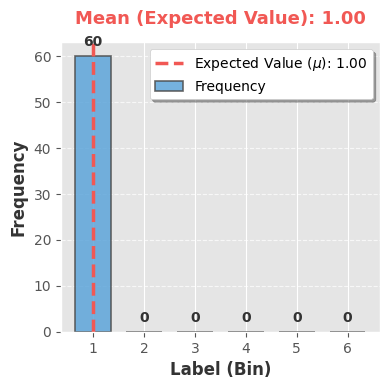

INITIAL BIAS


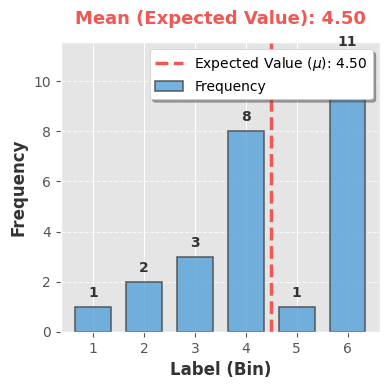

DICE SYSTEM GENERATED SUCCESSFULLY!! EXECITE NEXT CELL TO CHECK EVOLUTION


In [ ]:
D=int(input("ENTER THE LARGEST NUMBER : "))
ALPHA = int(input("ENTER THE NUMBER OF RANDOM NUMBER GENERATED EACH ITERATION: \n(RECOMMENED <4 FOR FAST ITERATIONS):  "))
print("------------ENTER THE INPUT FOR THE BIAS OF THE NUMBERS----------- ")
BIAS_ARRAY=np.zeros(D)
uniform_decision = int(input("ENTER THE 1 IF BIAS IS UNIFORM ELSE ENTER  2 : "))
if uniform_decision==1:
  BIAS_ARRAY=np.ones(D)
else:
  for i in range(D):
    d_i = float(input(f"ENTER THE BIAS FOR FACE: {i+1}: "))
    BIAS_ARRAY[i]=d_i
print("----------ENTER THE INITIAL DISTRIBUTION------------")
N_0=int(input("ENTER THE INITIAL NUMBER OF DATA GENERATED: "))
initial_dustribution = np.ones(D)*np.floor(N_0/D)
uniform_initial = int(input("ENTER \n 1) IF INITIAL DISTRIBUTION IS UNIFORM \n 2) IF INITIAL DISTRIBUTION IS SKEWED TO ONE NUMBER \n"))
if uniform_decision==2:
  skew_number = int(input("ENTER THE SKEWED NUMBR WHERE ALL INITIAL DATA IS GENERATED FOR: "))
  if skew_number>D:
    raise ValueError(f"Skewed Number should be less than {D}")
  initial_dustribution = np.zeros(D)
  initial_dustribution[skew_number-1]=1

  initial_dustribution =initial_dustribution*N_0


initial_state = DiceState(initial_dustribution)
print("INITIAL DISTRIBUTION")
initial_state.show()
initial_bias = DiceState(BIAS_ARRAY)
print("INITIAL BIAS")
initial_bias.show()

print("DICE SYSTEM GENERATED SUCCESSFULLY!! EXECITE NEXT CELL TO CHECK EVOLUTION")

ENTER THE NUMBER OF ITERATIONS TO EVOLVE: 90
ENTER THE NUMBER OF STEPS EACH ITERATIONS: 3
Generating 91 frames...
Compiling frames into distribution_evolution.gif...
GIF successfully created: distribution_evolution.gif

Displaying GIF in Colab output:


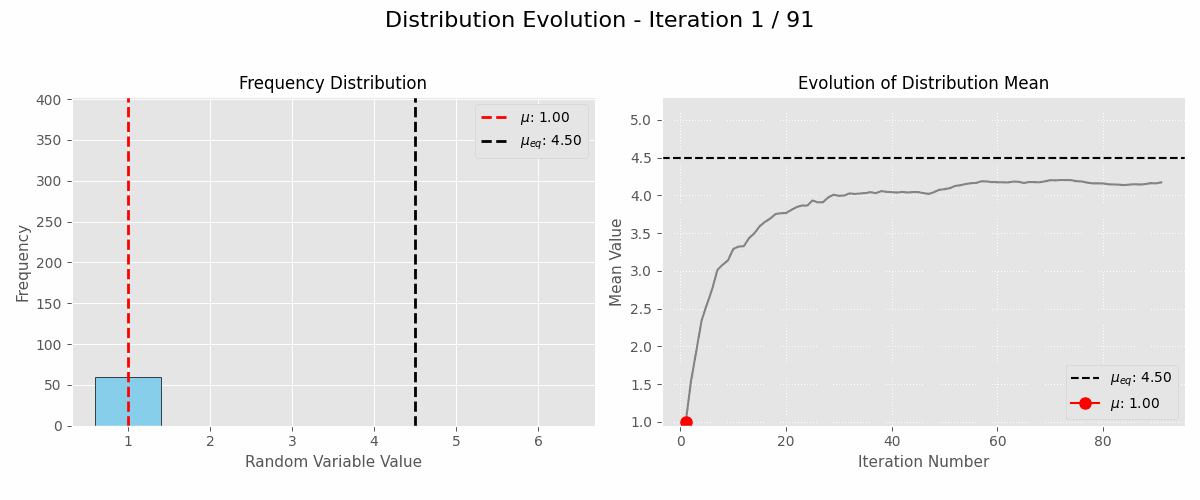

In [ ]:
random_dice_system_generated = RandomDiceFieldDynamicSystem(initial_state=initial_state,alpha=ALPHA,dice_number=D,bias_array=BIAS_ARRAY)

iteration_count= int(input("ENTER THE NUMBER OF ITERATIONS TO EVOLVE: "))
steps_count = int(input("ENTER THE NUMBER OF STEPS EACH ITERATIONS: "))
random_dice_system_generated.multi_iteration_evolution(iteration_count, steps_count)
random_dice_system_generated.visualize_distribution_evolution_gif(fps=10)